# TextGraphicalizer: first WordNet ontology pass

Run the Laya-backed `TextGraphicalizer` on made-up paragraphs using the checked-in high-level WordNet ontology. The estimator owns the parameterized graph display function, so rendering can be reused outside this notebook.

> The first model load downloads the pinned Laya checkpoint into the Hugging Face cache.

## One-time setup

Use the existing `py312` kernel backed by the project venv. From the repository root, run these commands once in a terminal:

```bash
source ~/.venvs/py312/bin/activate
python -m pip install -e ".[notebook]"
python -m ipykernel install --user --name py312 --display-name "py312"
```

In [1]:
from pathlib import Path
import sys

assert (3, 10) <= sys.version_info[:2] <= (3, 12), (
    f"Use a Python 3.10–3.12 kernel; current interpreter is {sys.version}"
)
print(f"Using Python: {sys.executable}")

import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "ontology.yaml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from textgraphicalizer import TextGraphicalizer

plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 15, "font.size": 10})
ontology_path = ROOT / "ontology.yaml"
stopwords_path = ROOT / "stopwords.yaml"
ontology_path

Using Python: /Users/f.costa/.venvs/py312/bin/python


PosixPath('/Users/f.costa/Code/TextGraphicalizer/ontology.yaml')

In [2]:
extractor = TextGraphicalizer(ontology=ontology_path, stopwords_path=stopwords_path)

## Multi-step paragraphs

In [ ]:
paragraphs = [
    ("Bridge inspection", "After engineers detected a crack in the aging bridge, the transport authority closed the route, redirected buses through the eastern district, and commissioned a reinforced replacement before winter storms."),
    ("Wildfire evacuation", "When a wildfire approached the national park, firefighters evacuated the campground, built a temporary barrier along the access road, and moved injured hikers to a regional clinic."),
    ("Irrigation project", "A prolonged drought damaged the wheat harvest, so the farming cooperative installed drip irrigation, stored grain in a new warehouse, and distributed emergency supplies to nearby villages."),
    ("River monitoring", "The university research team assembled a solar-powered sensor, tested it beside the river, and transmitted measurements to a city laboratory that monitored water quality."),
    ("Coastal restoration", "A coastal municipality approved a restoration project after repeated flooding eroded the dunes, relocated several homes, and planted native grasses to protect the harbor."),
]

In [8]:
extractor.node_threshold = 0.5
extractor.edge_threshold = 0.5
extractor.connected = True
extractor.max_node_degree = 4
extractor.use_milp = True

In [9]:

graphs = []
for title, paragraph in paragraphs:
    graph = extractor.transform(paragraph)
    graphs.append((title, paragraph, graph))
    print(f"{title}: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")

Storm response: 5 nodes, 8 edges
Drought and harvest: 5 nodes, 8 edges
Robot workshop: 5 nodes, 4 edges
Bridge inspection: 4 nodes, 8 edges
Wildfire evacuation: 3 nodes, 6 edges
Irrigation project: 4 nodes, 8 edges
River monitoring: 1 nodes, 0 edges
Coastal restoration: 4 nodes, 8 edges


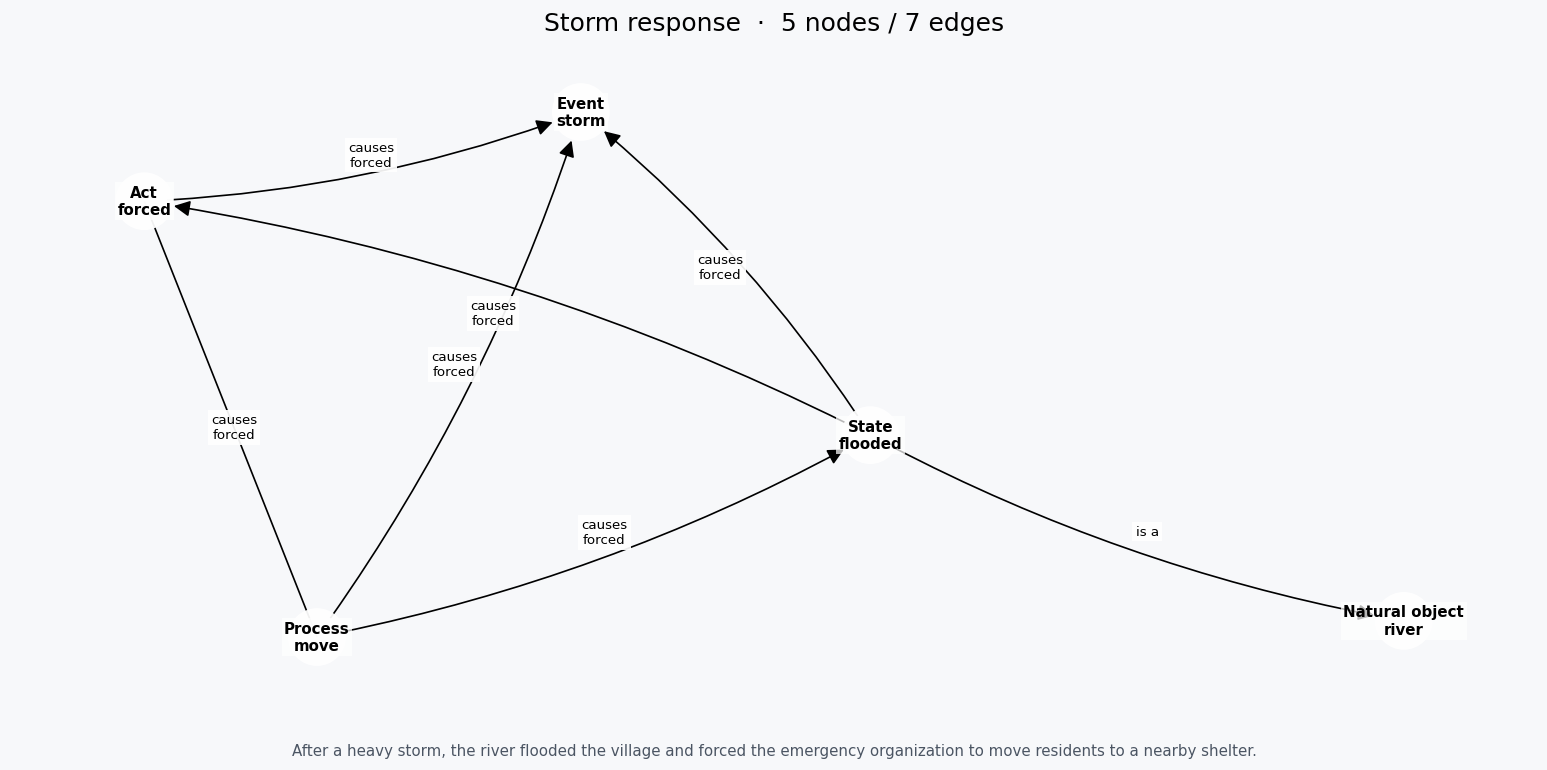

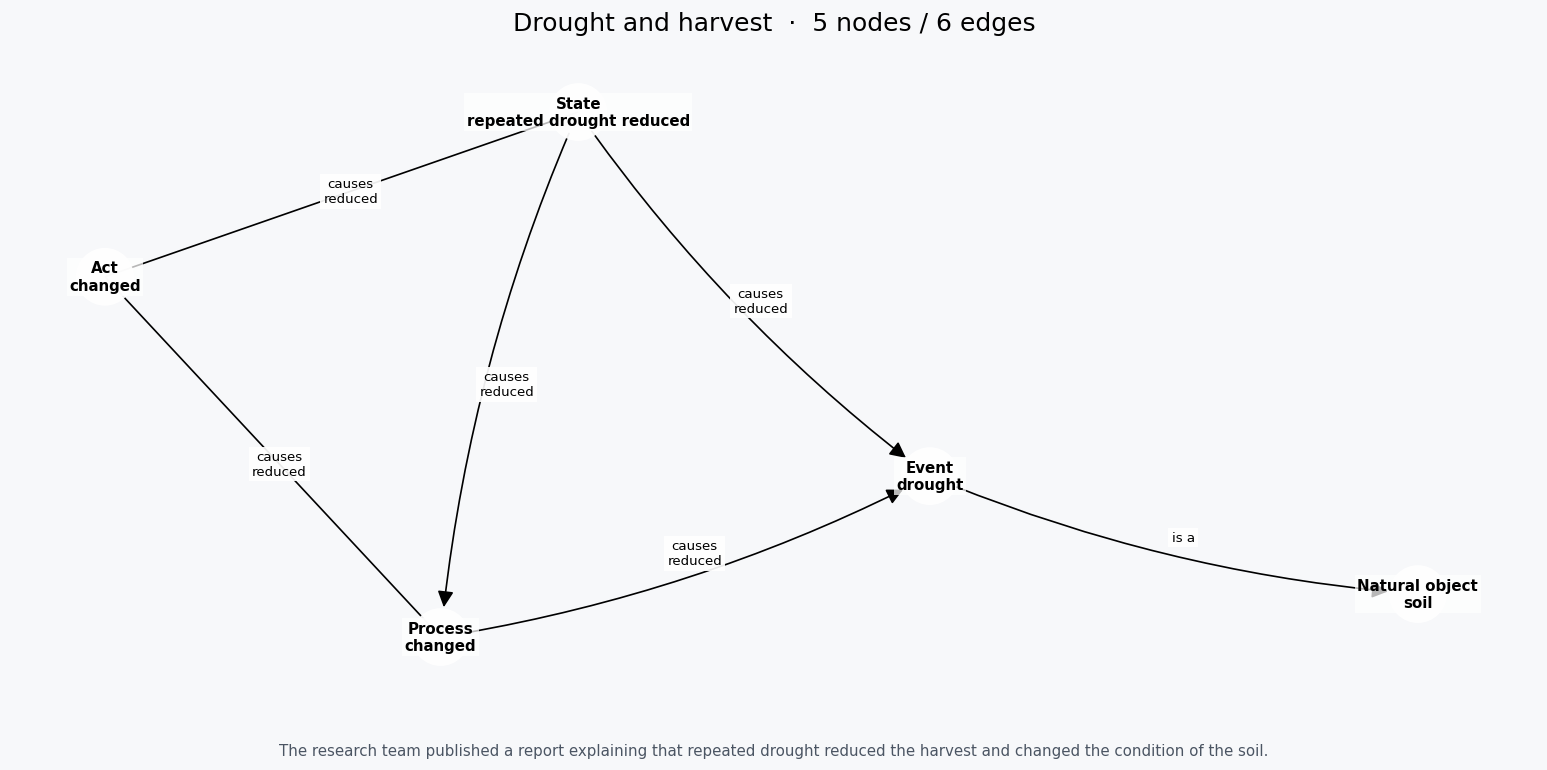

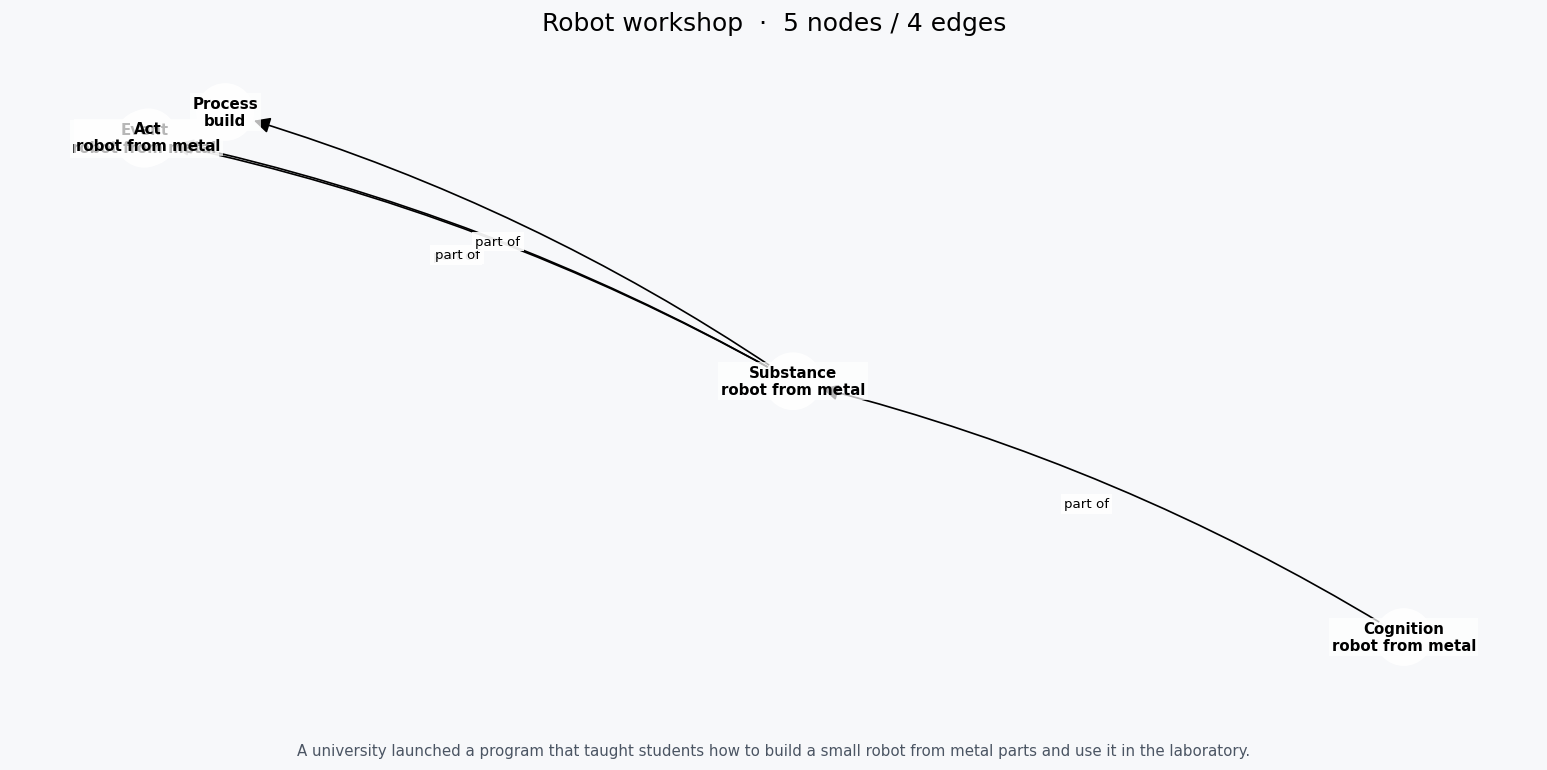

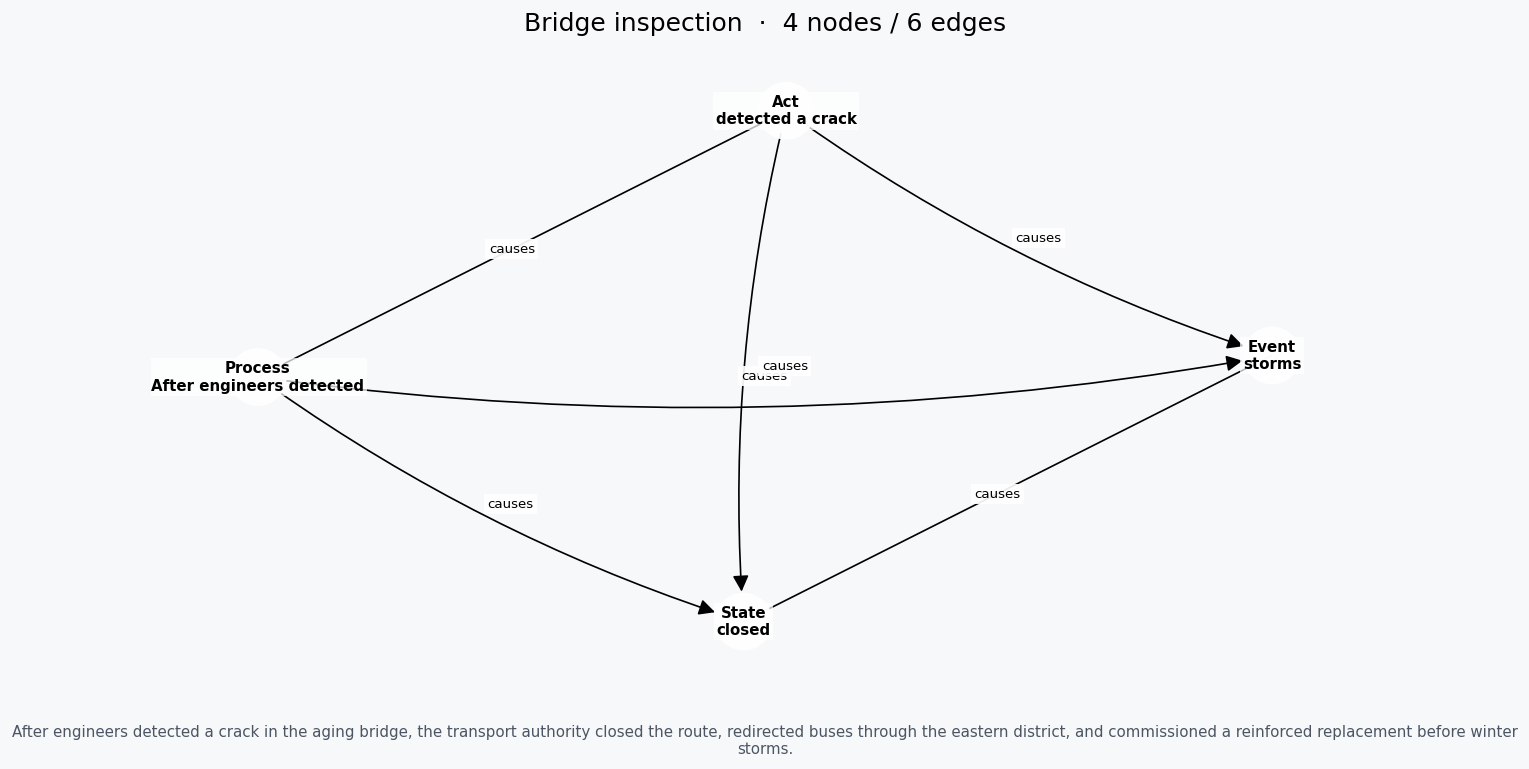

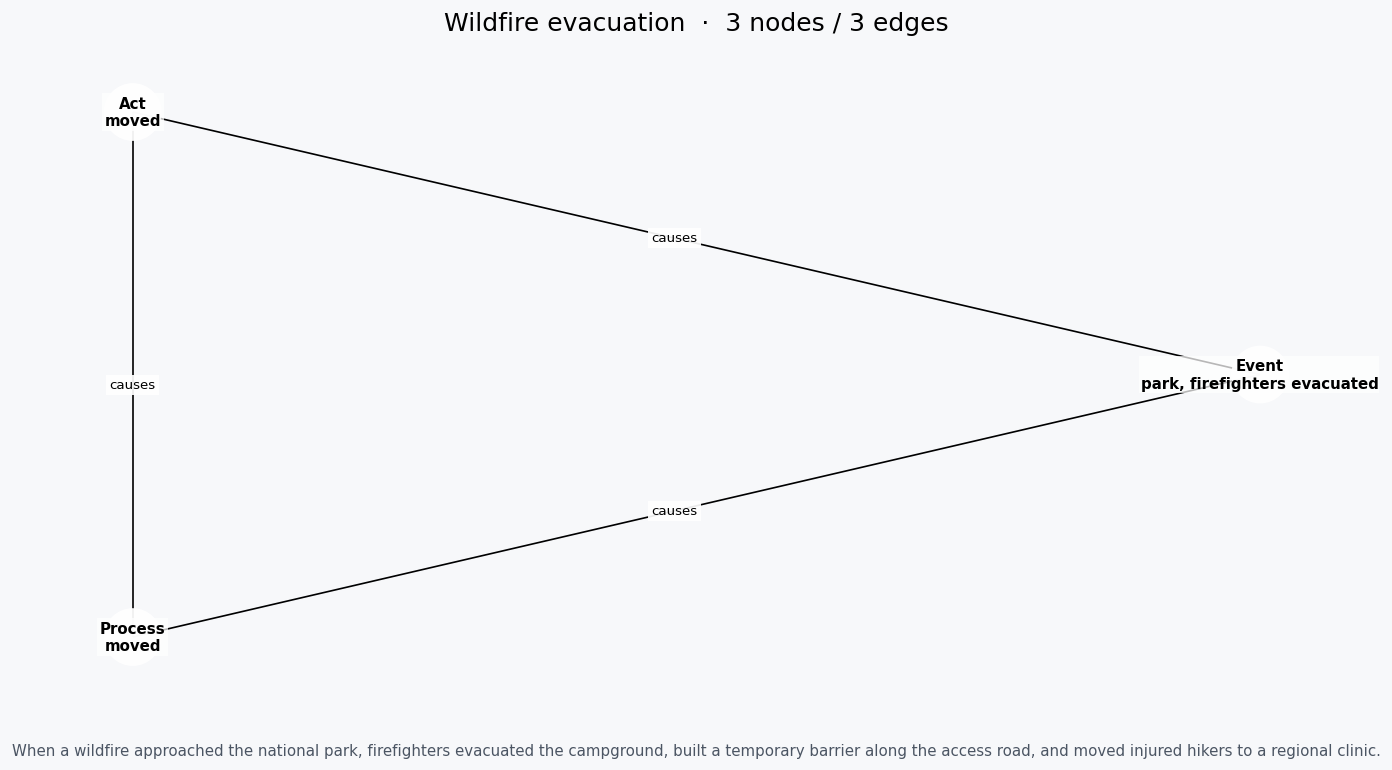

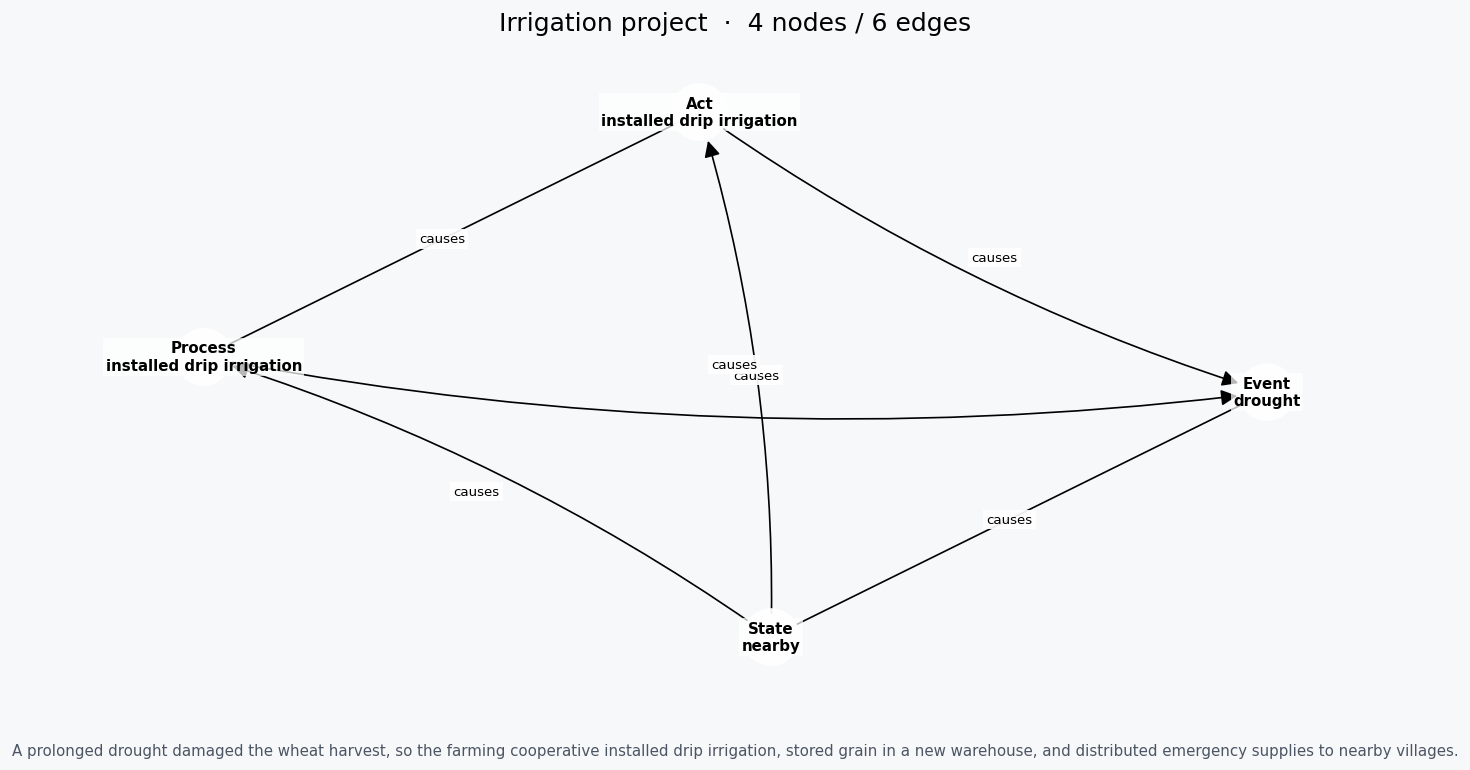

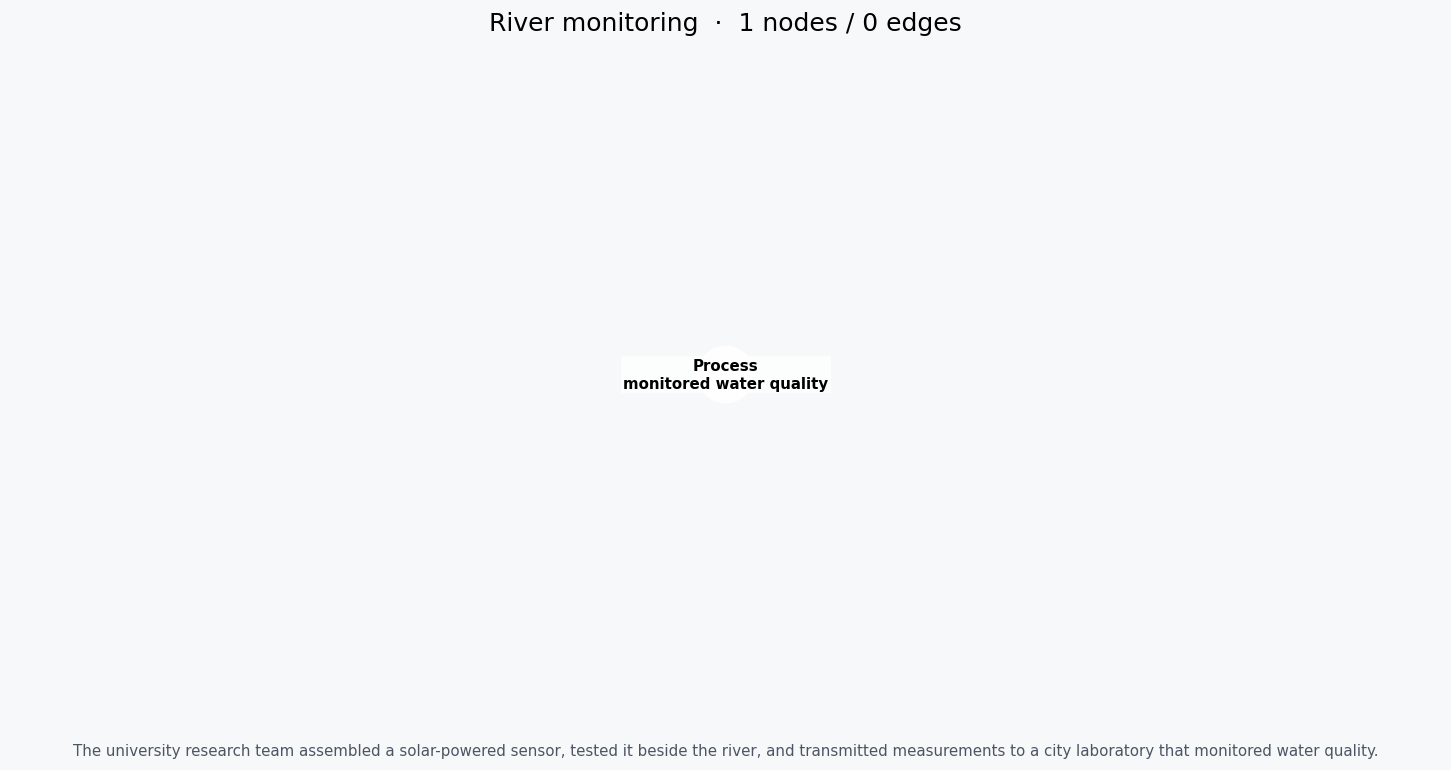

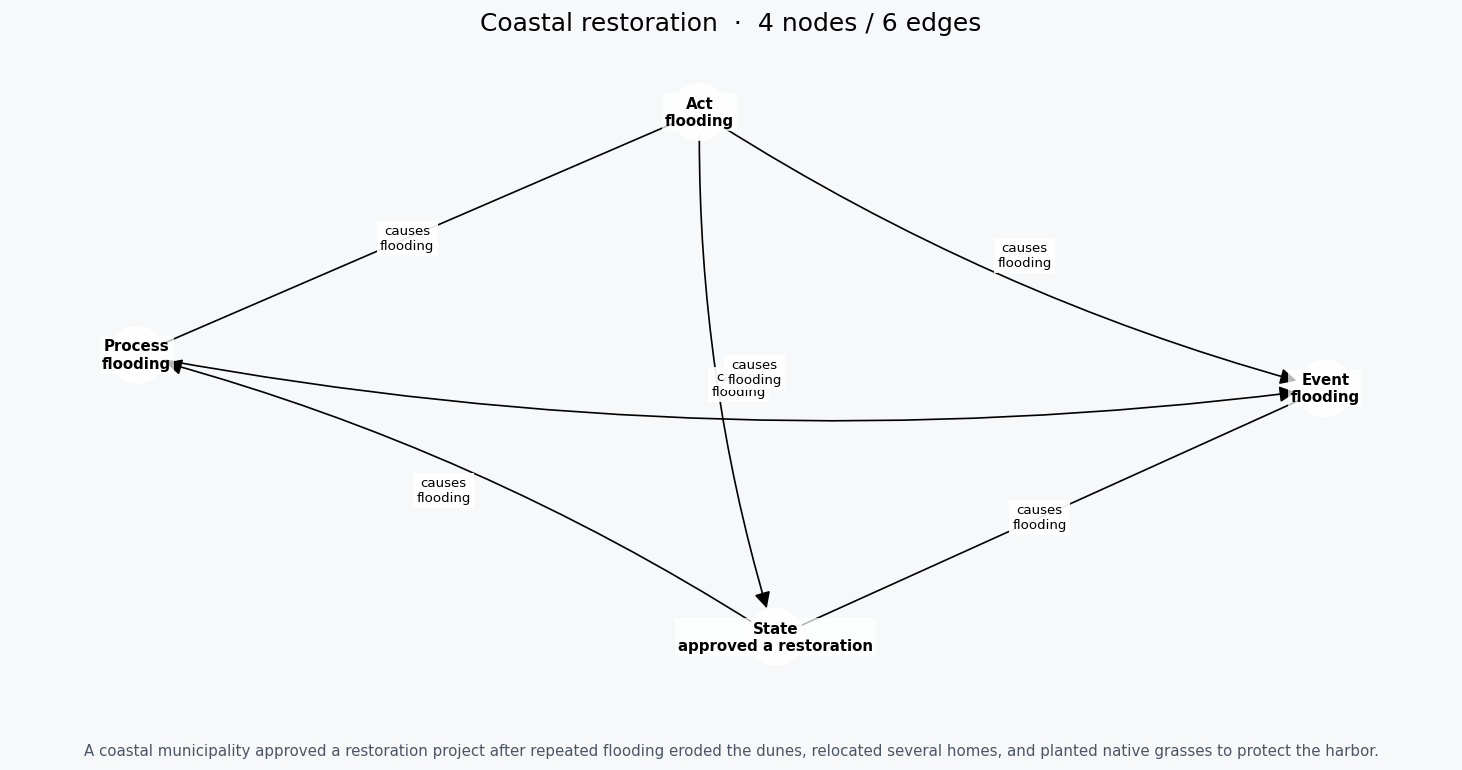

In [10]:
for title, paragraph, graph in graphs:
    extractor.display(graph, title=title, paragraph=paragraph)

## Inspect one graph as ordinary NetworkX data

In [11]:
title, paragraph, graph = graphs[2]
print("Nodes:")
display(list(graph.nodes(data=True)))
print("Edges:")
display(list(graph.edges(data=True)))
print("Graph metadata:")
display(graph.graph)

Nodes:


[('substance',
  {'label': 'Substance',
   'probability': 0.7457,
   'confidence': 0.7457,
   'span': 'robot from metal',
   'span_start': 13,
   'span_end': 16,
   'span_score': 0.30371713638305664,
   'grounding_candidates': [{'span': 'robot from metal',
     'score': 0.30371713638305664},
    {'span': 'launched a program', 'score': 0.2520255446434021},
    {'span': 'A university launched', 'score': 0.22824439406394958},
    {'span': 'from metal parts', 'score': 0.21471768617630005},
    {'span': 'small robot from', 'score': 0.2137395590543747}],
   'grounding_score_distribution': [{'span': 'robot from metal',
     'start_word': 13,
     'end_word': 16,
     'score': 0.30371713638305664},
    {'span': 'launched a program',
     'start_word': 2,
     'end_word': 5,
     'score': 0.2520255446434021},
    {'span': 'A university launched',
     'start_word': 0,
     'end_word': 3,
     'score': 0.22824439406394958},
    {'span': 'from metal parts',
     'start_word': 14,
     'end_word':

Edges:


[('substance',
  'event',
  {'label': 'part of',
   'probability': 0.4659,
   'existence_probability': 0.4659,
   'relation_probability': 0.4659,
   'confidence': 0.09}),
 ('substance',
  'act',
  {'label': 'part of',
   'probability': 0.4802,
   'existence_probability': 0.4802,
   'relation_probability': 0.4802,
   'confidence': 0.0988}),
 ('substance',
  'process',
  {'label': 'part of',
   'probability': 0.4692,
   'existence_probability': 0.4692,
   'relation_probability': 0.4692,
   'confidence': 0.0925}),
 ('cognition',
  'substance',
  {'label': 'part of',
   'probability': 0.4764,
   'existence_probability': 0.4764,
   'relation_probability': 0.4764,
   'confidence': 0.0962})]

Graph metadata:


{'ontology_version': 1,
 'model_id': 'convaiinnovations/laya',
 'model_revision': '7c76b622dfc5cac71b2dc1c29873efe2ce509a05',
 'node_threshold': 0.5,
 'edge_threshold': 0.5,
 'use_milp': True,
 'connected': True,
 'max_node_degree': 4,
 'solver': 'scipy.optimize.milp',
 'grounding_stopwords_removed': False,
 'stopwords_path': '/Users/f.costa/Code/TextGraphicalizer/stopwords.yaml',
 'stopwords_count': 174,
 'grounding_candidate_words': ['A',
  'university',
  'launched',
  'a',
  'program',
  'that',
  'taught',
  'students',
  'how',
  'to',
  'build',
  'a',
  'small',
  'robot',
  'from',
  'metal',
  'parts',
  'and',
  'use',
  'it',
  'in',
  'the',
  'laboratory'],
 'grounding_candidate_spans': ['A',
  'A university',
  'A university launched',
  'university',
  'university launched',
  'university launched a',
  'launched',
  'launched a',
  'launched a program',
  'a',
  'a program',
  'a program that',
  'program',
  'program that',
  'program that taught',
  'that',
  'that t